SIMPLE LINEAR REGRESSION ON HEIGHT WEIGHT


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [51]:
df=pd.read_csv('height-weight.csv')

In [52]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

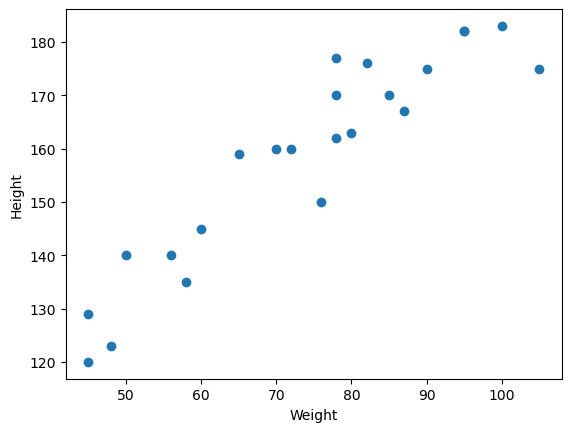

In [53]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [54]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


<Axes: >

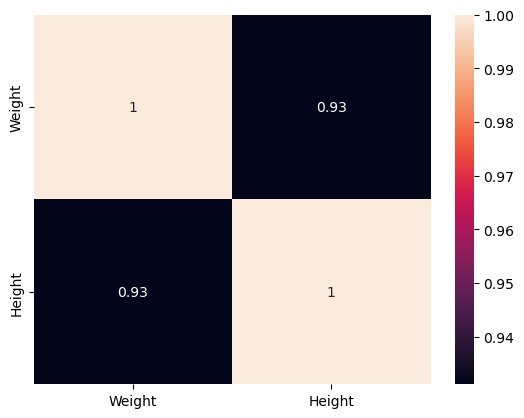

In [55]:
#corelation

sns.heatmap(df.corr(),annot=True)

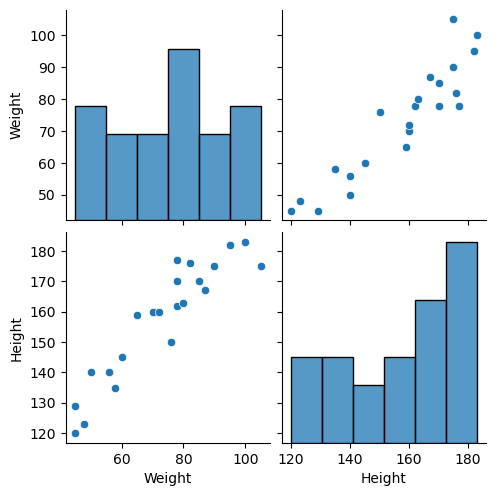

In [56]:
sns.pairplot(df)

In [57]:
#Independent feature should be dataframe and dependent feature should be series
X=df[['Weight']]
Y=df['Height']

In [58]:
X
Y

0     120
1     135
2     123
3     145
4     160
5     162
6     163
7     175
8     182
9     170
10    176
11    182
12    175
13    183
14    170
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64

In [59]:
#Train Test split
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25,random_state=42)
#random state is used to get the same result every time we run the code,if it is 42 



In [60]:
#Standardization
#z-score normalization mean=0 and standard deviation=1
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [61]:
X_train=scaler.fit_transform(X_train) #fit_transform is used to fit the scaler on the training data and then transform it
X_test=scaler.transform(X_test) #transform is used to transform the test data using the

In [62]:
from sklearn.linear_model import LinearRegression

regression=LinearRegression(n_jobs=-1)


In [63]:
regression.fit(X_train,Y_train)

LinearRegression(n_jobs=-1)

In [64]:
print('Coefficients:', regression.coef_) #1 unit change in weight will change the height by 17.2 units
print('Intercept:', regression.intercept_)# when weight is 0 height will be 156.47

Coefficients: [17.2982057]
Intercept: 156.47058823529412


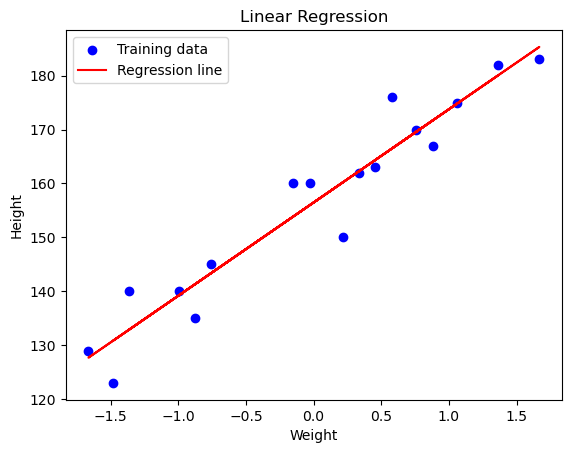

In [65]:
#plot tarining data
plt.scatter(X_train,Y_train,color='blue',label='Training data')
plt.plot(X_train,regression.predict(X_train),color='red',label='Regression line')
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Linear Regression')
plt.legend()
plt.show()

Predicting data
predicted_height_output=intercept+coeff(weights)
predicted_height_output=156.470+17.29(X_test) 

In [66]:
#predicting the test data ,this will give the predicted height for the given weight in the test data
y_pred=regression.predict(X_test)
y_pred

array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])

In [67]:
#Performance metrics

from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [68]:
mse=mean_squared_error(Y_test,y_pred)
mae=mean_absolute_error(Y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(Y_test,y_pred)

print('Mean Squared Error:', mse)
print('Mean Absolute Error:', mae)
print('Root Mean Squared Error:', rmse)
print('R2 Score:', r2)


Mean Squared Error: 114.84069295228699
Mean Absolute Error: 9.665125886795005
Root Mean Squared Error: 10.716374991212605
R2 Score: 0.7360826717981276


In [69]:
#display adjusted R2 score
n=len(Y_test) #number of samples in test data
p=X_test.shape[1] #number of features in test data
adjusted_r2=1-(1-r2)*(n-1)/(n-p-1)
print('Adjusted R2 Score:', adjusted_r2)

Adjusted R2 Score: 0.6701033397476595


In [70]:
#OLS-Ordinary Least Squares

import statsmodels.api as sm
model=sm.OLS(Y_train,X_train).fit()


In [71]:
prediction=model.predict(X_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [72]:
model.summary()


c:\Users\LENOVO\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Thu, 02 Apr 2026   Prob (F-statistic):                       0.664
Time:                        20:09:06   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            17.2982     39.138      0.442      0.664     -65.671     100.267
==============================================================================
Omnibus:                        0.135   Durbin-Watson:                   0.002
Prob(Omnibus):                  0.935   Jarque-Bera (JB):                0.203
Skew:                          -0.166   Prob(JB):                        0.904
Kurtosis:                       2.581   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [73]:
regression.predict(scaler.transform([[72]]))

c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])